In [75]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [76]:
df = pd.read_csv("/Users/becki/Desktop/diabetes_012_health_indicators_BRFSS2015.csv")

In [77]:
df.shape

(253680, 22)

In [78]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [80]:
df["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [81]:
df["Diabetes_012"].value_counts(normalize=True)

Diabetes_012
0.0    0.842412
2.0    0.139333
1.0    0.018255
Name: proportion, dtype: float64

The dataset shows class imbalance across the three categories.

In [82]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [83]:
df.duplicated().sum()

23899

In [84]:
df = df.drop_duplicates()

In [85]:
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

In [86]:
sensitive_features = ["Sex", "Age", "Income"]

In [87]:
df["Sex"].value_counts()
df["Age"].value_counts().sort_index()
df["Income"].value_counts().sort_index()

Income
1.0     9792
2.0    11757
3.0    15922
4.0    19957
5.0    25345
6.0    35001
7.0    40189
8.0    71818
Name: count, dtype: int64

In [88]:
pd.crosstab(df["Sex"], df["Diabetes_012"], normalize="index")

Diabetes_012,0.0,1.0,2.0
Sex,,,
0.0,0.837421,0.020209,0.142370
1.0,0.813955,0.020064,0.165981


In [89]:
pd.crosstab(df["Age"], df["Diabetes_012"], normalize="index")

Diabetes_012,0.0,1.0,2.0
Age,,,
1.0,0.982039,0.003810,0.014151
2.0,0.972552,0.007640,0.019808
3.0,0.961496,0.007182,0.031322
4.0,0.937306,0.011607,0.051087
5.0,0.913737,0.011601,0.074662
6.0,0.881323,0.018036,0.100642
7.0,0.849179,0.018064,0.132757
8.0,0.824512,0.020146,0.155342
9.0,0.785344,0.023608,0.191048


In [90]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [91]:
df.duplicated().sum()

0

In [92]:
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
sensitive_features = ["Sex", "Age", "Income"]

sensitive_test = X_test[sensitive_features].copy()

In [95]:
y.value_counts(normalize=True)

Diabetes_012
0.0    0.827114
2.0    0.152741
1.0    0.020145
Name: proportion, dtype: float64

In [96]:
y_train.value_counts(normalize=True)

Diabetes_012
0.0    0.827112
2.0    0.152744
1.0    0.020144
Name: proportion, dtype: float64

In [97]:
y_test.value_counts(normalize=True)

Diabetes_012
0.0    0.827121
2.0    0.152730
1.0    0.020149
Name: proportion, dtype: float64

In [98]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
class_weights

{0.0: 0.40300879794970285, 1.0: 16.547303987757672, 2.0: 2.1823016834057505}

Without handling class imbalance, the model tends to bias toward the majority class, leading to poor performance on minority classes.

In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Logistics Regression

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


log_reg = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    random_state=42,
    class_weight=class_weights
)

In [101]:
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

/Users/becki/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [102]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.6291533389907957


In [103]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.64      0.77     38012
         1.0       0.03      0.30      0.06       926
         2.0       0.37      0.59      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.84      0.63      0.70     45957



In [104]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))


Confusion Matrix:
[[24469  6729  6814]
 [  265   281   380]
 [ 1206  1649  4164]]


## Fairness 

In [105]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_group(mask, y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true[mask], y_pred[mask]),
        "f1": classification_report(y_true[mask], y_pred[mask], output_dict=True)["macro avg"]["f1-score"]
    }

In [106]:
male = sensitive_test["Sex"] == 1
female = sensitive_test["Sex"] == 0

print("Male:", evaluate_group(male, y_test, y_pred_log))
print("Female:", evaluate_group(female, y_test, y_pred_log))

Male: {'accuracy': 0.6208374384236454, 'f1': 0.4222507229556427}
Female: {'accuracy': 0.6357329383793896, 'f1': 0.4273612366487158}


In [107]:
young = sensitive_test["Age"] <= 6
old = sensitive_test["Age"] > 6

print("Young:", evaluate_group(young, y_test, y_pred_log))
print("Old:", evaluate_group(old, y_test, y_pred_log))

Young: {'accuracy': 0.8546262139576902, 'f1': 0.4479793947170249}
Old: {'accuracy': 0.5374915835220665, 'f1': 0.3970494723143077}


In [108]:
low = sensitive_test["Income"] <= 4
high = sensitive_test["Income"] > 4

print("Low income:", evaluate_group(low, y_test, y_pred_log))
print("High income:", evaluate_group(high, y_test, y_pred_log))

Low income: {'accuracy': 0.47677991396716707, 'f1': 0.3845239350072698}
High income: {'accuracy': 0.6793670080425852, 'f1': 0.42868424166279623}


Fairness Evaluation of Logistic Regression

The fairness evaluation shows that the Logistic Regression model performs similarly across sex groups, with only a small difference in both accuracy and macro F1-score between males and females. This suggests that there is no strong evidence of sex-based disparity in model performance.

However, larger performance gaps are observed across age and income groups. In particular, the model achieves substantially higher accuracy for younger individuals than for older individuals, and also performs better for high-income groups than for low-income groups. These differences indicate potential fairness concerns, suggesting that the model may not generalize equally well across all demographic and socioeconomic subgroups.

# Random Forest

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [110]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

In [111]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
y_pred_rf = rf_model.predict(X_test)

In [113]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.6491720521356921


In [114]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.66      0.77     38012
         1.0       0.03      0.18      0.05       926
         2.0       0.34      0.66      0.45      7019

    accuracy                           0.65     45957
   macro avg       0.44      0.50      0.42     45957
weighted avg       0.83      0.65      0.71     45957



In [115]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix:
[[25010  4437  8565]
 [  296   166   464]
 [ 1317  1044  4658]]


## Fairness

In [116]:
def evaluate_group(mask, y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true[mask], y_pred[mask]),
        "f1": classification_report(y_true[mask], y_pred[mask], output_dict=True)["macro avg"]["f1-score"]
    }

In [117]:
male = sensitive_test["Sex"] == 1
female = sensitive_test["Sex"] == 0

print("Male:", evaluate_group(male, y_test, y_pred_rf))
print("Female:", evaluate_group(female, y_test, y_pred_rf))

Male: {'accuracy': 0.6399507389162562, 'f1': 0.4231585679333509}
Female: {'accuracy': 0.6564680204232763, 'f1': 0.42584280822284165}


In [118]:
young = sensitive_test["Age"] <= 6
old = sensitive_test["Age"] > 6

print("Young:", evaluate_group(young, y_test, y_pred_rf))
print("Old:", evaluate_group(old, y_test, y_pred_rf))

Young: {'accuracy': 0.8531958141985997, 'f1': 0.44020778388440407}
Old: {'accuracy': 0.5662300299932668, 'f1': 0.3991589636312796}


In [119]:
low = sensitive_test["Income"] <= 4
high = sensitive_test["Income"] > 4

print("Low income:", evaluate_group(low, y_test, y_pred_rf))
print("High income:", evaluate_group(high, y_test, y_pred_rf))

Low income: {'accuracy': 0.5367395312088491, 'f1': 0.3983940882601205}
High income: {'accuracy': 0.686223456575826, 'f1': 0.4230633102036483}


Compared to Logistic Regression, Random Forest shows similar overall performance and slightly improved results for minority classes.

However, fairness analysis indicates that both models exhibit similar disparities across age and income groups.

This suggests that increasing model complexity does not necessarily improve fairness.

# XGBoost

In [120]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_group(mask, y_true, y_pred):
    report = classification_report(
        y_true[mask],
        y_pred[mask],
        output_dict=True,
        zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true[mask], y_pred[mask]),
        "f1": report["macro avg"]["f1-score"]
    }

In [121]:
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)

In [122]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [123]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8375437909350044


In [124]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91     38012
         1.0       0.00      0.00      0.00       926
         2.0       0.60      0.18      0.28      7019

    accuracy                           0.84     45957
   macro avg       0.48      0.39      0.40     45957
weighted avg       0.79      0.84      0.79     45957



/Users/becki/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/becki/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/becki/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [125]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


Confusion Matrix:
[[37229     0   783]
 [  852     0    74]
 [ 5757     0  1262]]


## Fairness

In [126]:
male = sensitive_test["Sex"] == 1
female = sensitive_test["Sex"] == 0

young = sensitive_test["Age"] <= 6
old = sensitive_test["Age"] > 6

low = sensitive_test["Income"] <= 4
high = sensitive_test["Income"] > 4

In [127]:
print("\nFairness - Sex")
print("Male:", evaluate_group(male, y_test, y_pred_xgb))
print("Female:", evaluate_group(female, y_test, y_pred_xgb))


Fairness - Sex
Male: {'accuracy': 0.8229556650246306, 'f1': 0.3863083993903336}
Female: {'accuracy': 0.8490860194099076, 'f1': 0.40306852081991557}


In [128]:
print("\nFairness - Age")
print("Young:", evaluate_group(young, y_test, y_pred_xgb))
print("Old:", evaluate_group(old, y_test, y_pred_xgb))


Fairness - Age
Young: {'accuracy': 0.9314160957614996, 'f1': 0.3812001392146642}
Old: {'accuracy': 0.7993817714390647, 'f1': 0.39070616774167616}


In [129]:
print("\nFairness - Income")
print("Low income:", evaluate_group(low, y_test, y_pred_xgb))
print("High income:", evaluate_group(high, y_test, y_pred_xgb))


Fairness - Income
Low income: {'accuracy': 0.7659555789658502, 'f1': 0.41364131612597305}
High income: {'accuracy': 0.861135219579934, 'f1': 0.37381664946460275}


# compare

In [130]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.629, 0.65, 0.838],
    "Macro F1": [0.43, 0.42, 0.40],
    "Sex Fairness": ["Small gap", "Small gap", "Small gap"],
    "Age Fairness": ["Large gap", "Large gap", "Smaller F1 gap"],
    "Income Fairness": ["Large gap", "Large gap", "Mixed result"]
})

comparison_table

,Model,Accuracy,Macro F1,Sex Fairness,Age Fairness,Income Fairness
0,Logistic Regression,0.629,0.43,Small gap,Large gap,Large gap
1,Random Forest,0.650,0.42,Small gap,Large gap,Large gap
2,XGBoost,0.838,0.40,Small gap,Smaller F1 gap,Mixed result


XGBoost improves accuracy but reduces balanced performance across classes.

Increasing model complexity does not eliminate fairness issues.

Fairness conclusions vary depending on whether accuracy or macro F1 is used.

XGBoost is the most accurate model, but it is not the most balanced or fair model.

# Shap

In [134]:
X_sample = X_test.sample(1000, random_state=42)

In [135]:
import shap

explainer = shap.TreeExplainer(xgb_model)

In [136]:
shap_values = explainer.shap_values(X_sample)

In [138]:
import numpy as np

print(type(shap_values))

if hasattr(shap_values, "shape"):
    print("shap_values.shape =", shap_values.shape)

print("X_sample.shape =", X_sample.shape)

<class 'numpy.ndarray'>
shap_values.shape = (1000, 21, 3)
X_sample.shape = (1000, 21)


In [140]:
shap_class2 = shap_values[:, :, 2]

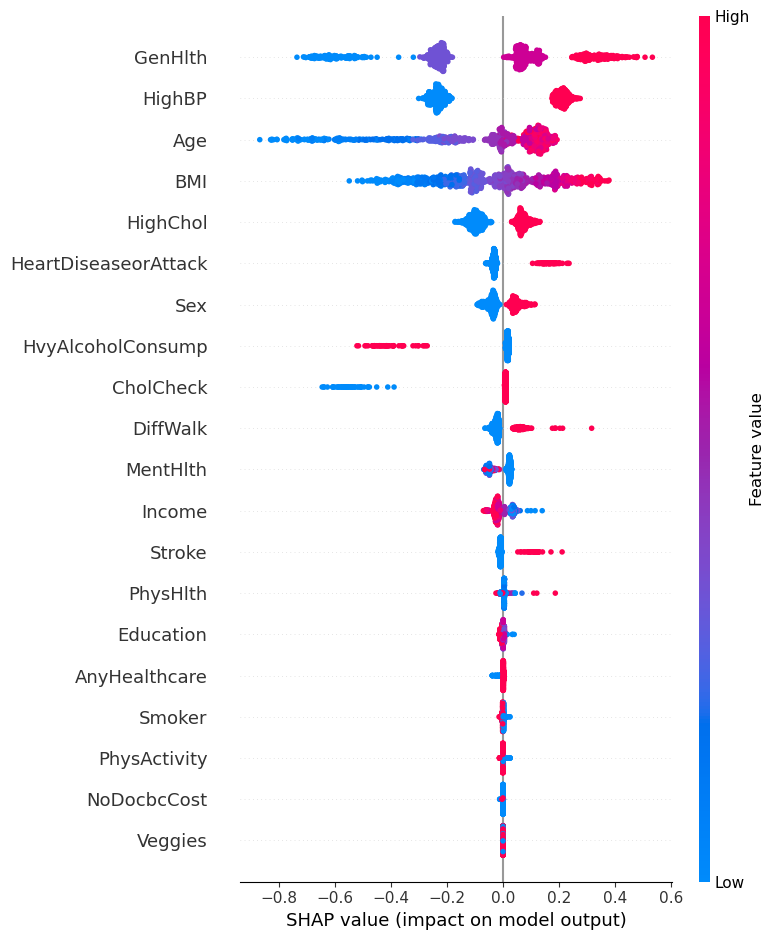

In [141]:
shap.summary_plot(shap_class2, X_sample)

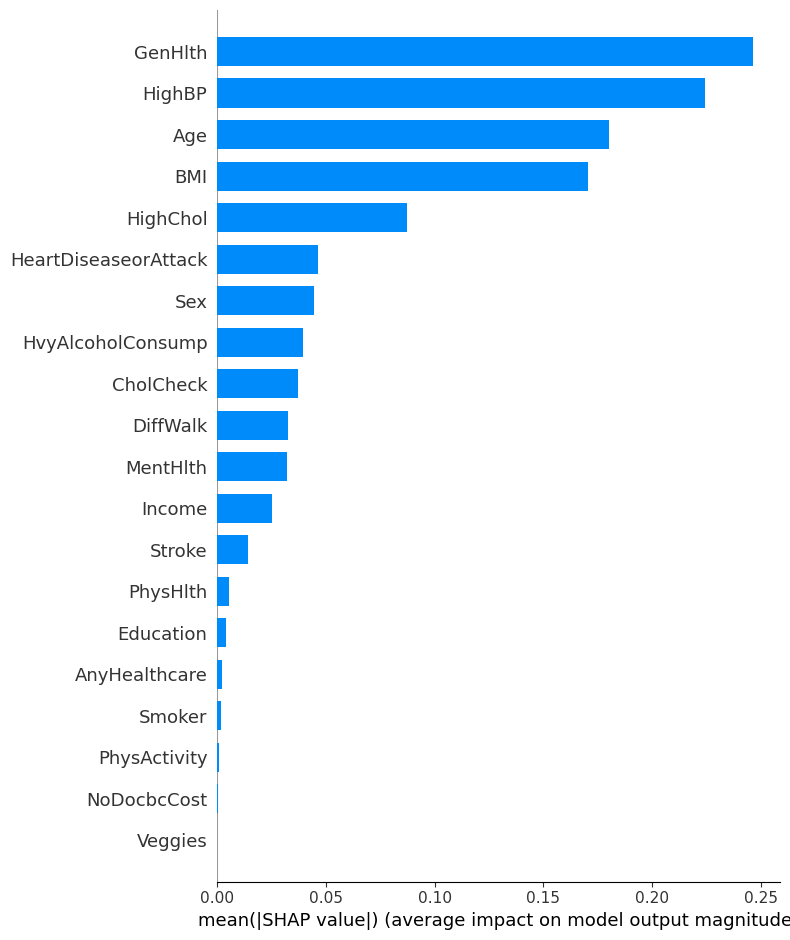

In [142]:
shap.summary_plot(shap_class2, X_sample, plot_type="bar")

Lifestyle-related variables have relatively low importance in the model, suggesting that the model prioritizes physiological indicators over behavioral factors.

The model mainly relies on strong medical risk factors (BMI, age, health condition), which improves accuracy but limits its ability to detect subtle cases such as pre-diabetes.